In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
IBS_time = pd.read_table('IBS_data.dat', sep="\s+")
structure = pd.read_table('IBS_structure.dat', sep="\s+")
beam = pd.read_table('IBS_beam.dat', sep="\s+")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Professional\AppData\Local\Temp\ipykernel_14784\1280217862.py:1: SyntaxWarning: invalid escape sequence '\s'
  IBS_time = pd.read_table('IBS_data.dat', sep="\s+")
C:\Users\Professional\AppData\Local\Temp\ipykernel_14784\1280217862.py:2: SyntaxWarning: invalid escape sequence '\s'
  structure = pd.read_table('IBS_structure.dat', sep="\s+")
C:\Users\Professional\AppData\Local\Temp\ipykernel_14784\1280217862.py:3: SyntaxWarning: invalid escape sequence '\s'
  beam = pd.read_table('IBS_beam.dat', sep="\s+")


In [4]:
# do same but attach it to the dataframe
IBS_time['t_all'] = IBS_time.apply(lambda row: 1/((1/np.abs(row.t_h)) + (1/np.abs(row.t_v))), axis=1)
IBS_time['t_l_abs'] = IBS_time.apply(lambda row: np.abs(row.t_l), axis=1)
IBS_time['t'] = IBS_time[['t_l_abs','t_h', 't_v']].min(axis=1)
print(IBS_time)

               structure  kinetic_energy          t_l          t_h  \
0                Regular             1.0    -85.82334    13.917530   
1                Regular             1.5   -185.90450    56.229110   
2                Regular             2.0   -406.50980   176.853800   
3                Regular             2.5   -938.57820   460.800300   
4                Regular             3.0  -2663.85700  1006.000000   
5                Regular             3.5 -37218.42000  1833.558000   
6                Regular             4.0   6729.26500  2821.348000   
7                Regular             4.5   4285.50800  3798.158000   
8                Regular             5.0   3711.49700  4677.738000   
9               Resonant             1.0   -117.87370     4.903227   
10              Resonant             1.5   -271.32900    13.129790   
11              Resonant             2.0   -647.47400    26.839350   
12              Resonant             2.5  -1779.19600    46.553990   
13              Reso

In [5]:
#print(IBS_time)
#temp_X = parameters_X.merge(particles_X, on=['I'])
#data_X = temp_X.merge(tss_X, on=['I'])
#IBS_time[IBS_time['structure'] == 'Regular'].plot('kinetic_energy', y = ['t_l', 't_h', 't_v'])
#IBS_time[IBS_time['structure'] == 'Resonant'].plot('kinetic_energy', y = ['t_l', 't_h', 't_v'])
#IBS_time[IBS_time['structure'] == 'Regular_and_Resonant'].plot('kinetic_energy', y = ['t_l', 't_h', 't_v'])

regular = IBS_time[IBS_time['structure'] == 'Regular']
resonant = IBS_time[IBS_time['structure'] == 'Resonant']
regular_and_resonant = IBS_time[IBS_time['structure'] == 'Regular_and_Resonant']
print(regular)

  structure  kinetic_energy          t_l         t_h          t_v      sigE  \
0   Regular             1.0    -85.82334    13.91753     6.465175  2.084909   
1   Regular             1.5   -185.90450    56.22911    23.079230  1.875210   
2   Regular             2.0   -406.50980   176.85380    65.152610  1.779691   
3   Regular             2.5   -938.57820   460.80030   158.574300  1.727279   
4   Regular             3.0  -2663.85700  1006.00000   348.606600  1.695160   
5   Regular             3.5 -37218.42000  1833.55800   712.504900  1.673961   
6   Regular             4.0   6729.26500  2821.34800  1381.137000  1.659197   
7   Regular             4.5   4285.50800  3798.15800  2577.765000  1.648485   
8   Regular             5.0   3711.49700  4677.73800  4691.840000  1.640457   

         t_all      t_l_abs            t  
0     4.414491     85.82334     6.465175  
1    16.363028    185.90450    23.079230  
2    47.612320    406.50980    65.152610  
3   117.975592    938.57820   158.574

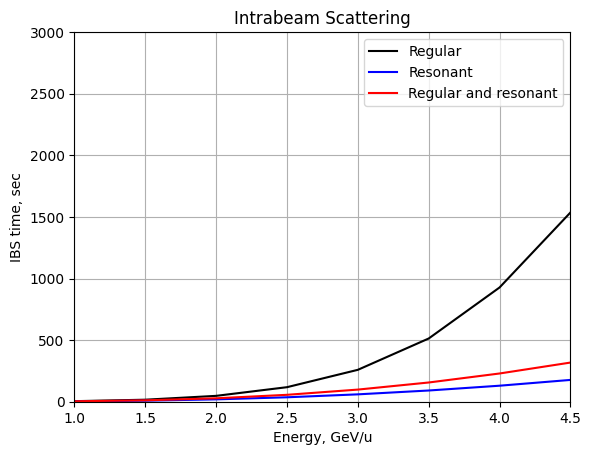

In [6]:
plt.plot(regular['kinetic_energy'], regular['t_all'], 'k')
plt.plot(resonant['kinetic_energy'], resonant['t_all'], 'b')
plt.plot(regular_and_resonant['kinetic_energy'], regular_and_resonant['t_all'], 'r')
plt.legend(['Regular', 'Resonant', 'Regular and resonant'])
plt.title("Intrabeam Scattering")
plt.xlabel('Energy, GeV/u')
plt.ylabel('IBS time, sec')
plt.grid()
plt.xlim(1, 4.5)
plt.ylim(0, 3000)
plt.show()

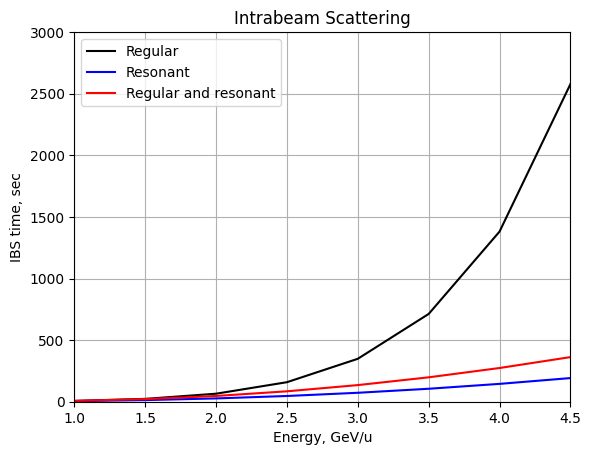

In [7]:
plt.plot(regular['kinetic_energy'], regular['t'], 'k')
plt.plot(resonant['kinetic_energy'], resonant['t'], 'b')
plt.plot(regular_and_resonant['kinetic_energy'], regular_and_resonant['t'], 'r')
plt.legend(['Regular', 'Resonant', 'Regular and resonant'])
plt.title("Intrabeam Scattering")
plt.xlabel('Energy, GeV/u')
plt.ylabel('IBS time, sec')
plt.grid()
plt.xlim(1, 4.5)
plt.ylim(0, 3000)
plt.show()

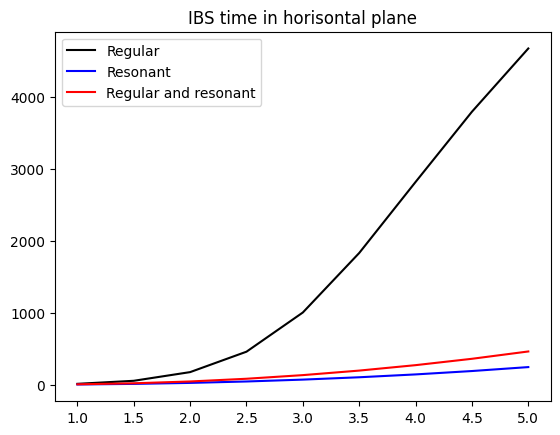

In [9]:
plt.plot(regular['kinetic_energy'], regular['t_h'], 'k')
plt.plot(resonant['kinetic_energy'], resonant['t_h'], 'b')
plt.plot(regular_and_resonant['kinetic_energy'], regular_and_resonant['t_h'], 'r')
plt.legend(['Regular', 'Resonant', 'Regular and resonant'])
plt.title("IBS time in horisontal plane")
plt.show()

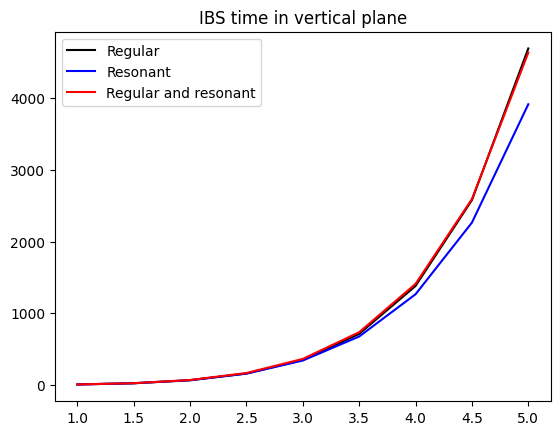

In [10]:
plt.plot(regular['kinetic_energy'], regular['t_v'], 'k')
plt.plot(resonant['kinetic_energy'], resonant['t_v'], 'b')
plt.plot(regular_and_resonant['kinetic_energy'], regular_and_resonant['t_v'], 'r')
plt.legend(['Regular', 'Resonant', 'Regular and resonant'])
plt.title("IBS time in vertical plane")
plt.show()

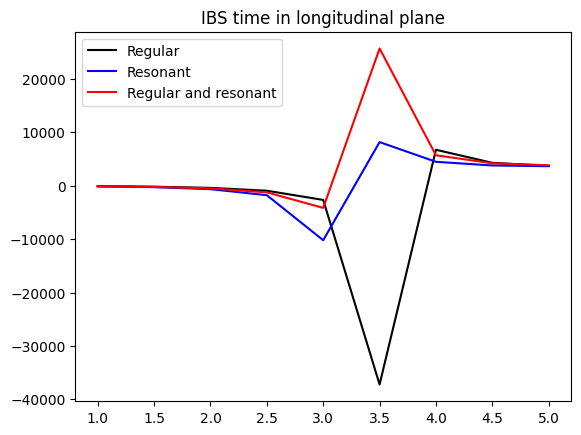

In [11]:
plt.plot(regular['kinetic_energy'], regular['t_l'], 'k')
plt.plot(resonant['kinetic_energy'], resonant['t_l'], 'b')
plt.plot(regular_and_resonant['kinetic_energy'], regular_and_resonant['t_l'], 'r')
plt.legend(['Regular', 'Resonant', 'Regular and resonant'])
plt.title("IBS time in longitudinal plane")
plt.show()